## Utrecht University - Network Science

The data is obtained from https://github.com/statsbomb/open-data. The data is provided as json files and it is freely available to enhance understanding of the game of Football, to actively encourage new research and analysis at all levels in Football Analytics. The structure of the data is the following:

> **competitions.json**: It is a dictionary file containing the key identifiers that correspond to each different competition of each different country and different season (year). 

> **open-data/data/matches/comp_id/season_id.json**: It is a json file that contains basic information about all the matches that were played during an entire season. It includes the teams playing, the matchday, result, coaches, stadium...
We have selected the json file called '90.json' which corresponds to all the matches played throughout the 2020/2021 Spanish La Liga competition. In this case, the file contains only 35 matches corresponding to those involving FC.Barcelona. 

> **open-data/data/events/match_id.json**: It is a json file that contains detailed information about all type of events that were produced during a single game. Each file is named for a match ID.





In [1]:
# Importing necessary libraries
import pandas as pd
import json
from pathlib import Path


# Reading the file that contains the basic information about all the matches played for LaLiga 2020/2021 season 
with open("90.json", "r", encoding="utf-8") as f:
    data_matches = json.load(f)
# matches = pd.read_json("27.json")
matches = pd.json_normalize(data_matches)

print(matches.columns.tolist())

print("Total number of matches from this season LaLiga 2020/2021: ", len(matches))

# Filtering the dataset for only the matches of the team we are interested in
team_name = "Barcelona"

team_matches = matches[
    (matches["home_team.home_team_name"] == team_name) |
    (matches["away_team.away_team_name"] == team_name)]


print("Total number of games that there are for FC.Barcelona in this season: ", len(team_matches))

['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition.competition_id', 'competition.country_name', 'competition.competition_name', 'season.season_id', 'season.season_name', 'home_team.home_team_id', 'home_team.home_team_name', 'home_team.home_team_gender', 'home_team.home_team_group', 'home_team.country.id', 'home_team.country.name', 'home_team.managers', 'away_team.away_team_id', 'away_team.away_team_name', 'away_team.away_team_gender', 'away_team.away_team_group', 'away_team.country.id', 'away_team.country.name', 'away_team.managers', 'metadata.data_version', 'metadata.shot_fidelity_version', 'metadata.xy_fidelity_version', 'competition_stage.id', 'competition_stage.name', 'stadium.id', 'stadium.name', 'stadium.country.id', 'stadium.country.name', 'referee.id', 'referee.name', 'referee.country.id', 'referee.country.name']
Total number of matches from this season LaLiga 2020

In [2]:
# Checking the identifiers for the matches that we have for our team
team_matches['match_id'].unique()

array([3773386, 3773565, 3773457, 3773631, 3773665, 3773497, 3773660,
       3773593, 3773466, 3773585, 3773552, 3773672, 3773587, 3773656,
       3773377, 3773586, 3773372, 3773387, 3773695, 3773369, 3773661,
       3773597, 3773523, 3773571, 3773428, 3764661, 3773526, 3773474,
       3773625, 3773403, 3773547, 3773415, 3764440, 3773689, 3773477])

In [3]:
# Setting option to be able to see all the columns of our dataset
pd.set_option('display.max_columns', None)

# List of the matches we are interested in studying
match_ids = [3773386, 3773565, 3773457, 3773631, 3773665, 3773497, 3773660,
            3773593, 3773466, 3773585, 3773552, 3773672, 3773587, 3773656,
            3773377, 3773586, 3773372, 3773387, 3773695, 3773369, 3773661,
            3773597, 3773523, 3773571, 3773428, 3764661, 3773526, 3773474,
            3773625, 3773403, 3773547, 3773415, 3764440, 3773689, 3773477]


# List to gather all the data from all the desired matches, corresponding to passing events
data_all_passes = []

# Reading the json files that correspond to the detailet event data of each of the matches we are interested in studying
for match_id in match_ids:
    # Adding the variable as a name of the file
    file_path = Path(f"{match_id}.json")
    
    # Reading the file
    with open(file_path, "r", encoding="utf-8") as f:
        data_events = json.load(f)
    events = pd.json_normalize(data_events)
    
    # Filtering for only those events that correspond to passes
    passes = events[events["type.name"] == "Pass"].copy()
    
    # Adding a match_id feature to know from which match comes every pass
    passes["match_id"] = match_id
    
    data_all_passes.append(passes)

    
# Big DataFrame with all the passes from all the matches
passes_all_matches = pd.concat(data_all_passes, ignore_index=True)


print("Total passes:", len(passes_all_matches))
print("Total matches loaded:", passes_all_matches["match_id"].nunique())

# Checking the obtained dataset
passes_all_matches.head()    

Total passes: 40337
Total matches loaded: 35


,id,index,period,timestamp,minute,second,possession,duration,type.id,type.name,possession_team.id,possession_team.name,play_pattern.id,play_pattern.name,team.id,team.name,tactics.formation,tactics.lineup,related_events,location,player.id,player.name,position.id,position.name,pass.recipient.id,pass.recipient.name,pass.length,pass.angle,pass.height.id,pass.height.name,pass.end_location,pass.body_part.id,pass.body_part.name,pass.type.id,pass.type.name,carry.end_location,under_pressure,pass.outcome.id,pass.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,counterpress,dribble.outcome.id,dribble.outcome.name,foul_committed.advantage,foul_won.advantage,duel.type.id,duel.type.name,duel.outcome.id,duel.outcome.name,pass.aerial_won,pass.switch,pass.technique.id,pass.technique.name,pass.through_ball,clearance.body_part.id,clearance.body_part.name,clearance.left_foot,out,off_camera,pass.deflected,pass.cross,clearance.head,pass.outswinging,interception.outcome.id,interception.outcome.name,pass.assisted_shot_id,pass.shot_assist,shot.one_on_one,shot.statsbomb_xg,shot.end_location,shot.key_pass_id,shot.type.id,shot.type.name,shot.outcome.id,shot.outcome.name,shot.technique.id,shot.technique.name,shot.body_part.id,shot.body_part.name,shot.freeze_frame,goalkeeper.end_location,goalkeeper.position.id,goalkeeper.position.name,goalkeeper.type.id,goalkeeper.type.name,foul_won.defensive,foul_committed.card.id,foul_committed.card.name,shot.first_time,goalkeeper.body_part.id,goalkeeper.body_part.name,goalkeeper.outcome.id,goalkeeper.outcome.name,goalkeeper.technique.id,goalkeeper.technique.name,dribble.overrun,ball_recovery.offensive,pass.no_touch,clearance.right_foot,ball_recovery.recovery_failure,dribble.nutmeg,pass.cut_back,miscontrol.aerial_won,shot.open_goal,shot.aerial_won,clearance.aerial_won,bad_behaviour.card.id,bad_behaviour.card.name,substitution.outcome.id,substitution.outcome.name,substitution.replacement.id,substitution.replacement.name,pass.inswinging,foul_committed.offensive,foul_committed.type.id,foul_committed.type.name,50_50.outcome.id,50_50.outcome.name,match_id,pass.straight,pass.goal_assist,block.offensive,clearance.other,block.deflection,shot.deflected,injury_stoppage.in_chain,pass.miscommunication,foul_committed.penalty,foul_won.penalty,goalkeeper.punched_out,shot.saved_off_target,goalkeeper.shot_saved_off_target,shot.saved_to_post,goalkeeper.shot_saved_to_post,block.save_block,dribble.no_touch,shot.redirect,shot.follows_dribble
0,208f072d-cffa-4575-bd73-e9e9384c8fe1,5,1,00:00:00.689,0,0,2,0.963571,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[1b0529a5-c699-44e4-b534-80a48503d3a8],"[61.0, 40.1]",5487.0,Antoine Griezmann,23.0,Center Forward,5203.0,Sergio Busquets i Burgos,12.210241,2.692596,1.0,Ground Pass,"[50.0, 45.4]",38.0,Left Foot,65.0,Kick Off,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,e1f11e14-fb24-4c82-868f-507385122b9c,7,1,00:00:01.653,0,1,2,0.998827,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[b9c89821-9722-4c12-ada7-e1d09cc10a89],"[49.4, 44.9]",5203.0,Sergio Busquets i Burgos,9.0,Right Defensive Midfield,8118.0,Frenkie de Jong,15.471910,-1.720006,1.0,Ground Pass,"[47.1, 29.6]",40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [4]:
# Retaining only the useful features of our dataset to construct the Passing Network Dataset
passes_network = passes_all_matches[[
    "match_id",
    "team.name",
    "player.name",
    "position.name",
    "pass.recipient.name",
    "location",
    "pass.end_location",
    "pass.length",
    "pass.angle",
    "pass.height.name",
    "pass.outcome.name"
]].copy()

passes_network.head()

,match_id,team.name,player.name,position.name,pass.recipient.name,location,pass.end_location,pass.length,pass.angle,pass.height.name,pass.outcome.name
0,3773386,Barcelona,Antoine Griezmann,Center Forward,Sergio Busquets i Burgos,"[61.0, 40.1]","[50.0, 45.4]",12.210241,2.692596,Ground Pass,NaN
1,3773386,Barcelona,Sergio Busquets i Burgos,Right Defensive Midfield,Frenkie de Jong,"[49.4, 44.9]","[47.1, 29.6]",15.471910,-1.720006,Ground Pass,NaN
2,3773386,Barcelona,Frenkie de Jong,Left Defensive Midfield,Gerard Piqué Bernabéu,"[48.1, 29.6]","[35.5, 50.6]",24.489998,2.111216,Ground Pass,NaN
3,3773386,Barcelona,Gerard Piqué Bernabéu,Right Center Back,Clément Lenglet,"[44.3, 50.2]","[41.0, 29.7]",20.763910,-1.730403,Ground Pass,NaN
4,3773386,Barcelona,Clément Lenglet,Left Center Back,Sergio Busquets i Burgos,"[49.0, 28.7]","[57.8, 33.5]",10.023972,0.499347,Ground Pass,NaN


In [5]:
# The dataset contains all the passes produced by both teams along all the matches that FC.Barcelona has played
passes_network['team.name'].unique()

array(['Barcelona', 'Deportivo Alavés', 'Granada', 'Celta Vigo',
       'Real Betis', 'Osasuna', 'Real Madrid', 'Levante UD', 'Villarreal',
       'Huesca', 'Sevilla', 'Getafe', 'Atlético Madrid', 'Valencia',
       'Real Sociedad', 'Real Valladolid', 'Cádiz', 'Athletic Club',
       'Elche'], dtype=object)

In [6]:
# We only want to retain the data corresponding to passes made by FC.Barcelona during their matches, not from the opponent
fcb_passes = passes_network[
    (passes_network["team.name"] == "Barcelona") &
    (passes_network["pass.recipient.name"].notna()) &
    (passes_network["pass.outcome.name"].isna())
].copy()

# Checking the amount of passes that FC.Barcelona has completed, for each match they played during the season:
passes_per_match = (fcb_passes.groupby("match_id").size().reset_index(name="num_passes"))
print(passes_per_match)

    match_id  num_passes
0    3764440         723
1    3764661         610
2    3773369         871
3    3773372         571
4    3773377         667
5    3773386         784
6    3773387         577
7    3773403         559
8    3773415         857
9    3773428         801
10   3773457         688
11   3773466         504
12   3773474         658
13   3773477         573
14   3773497         666
15   3773523         447
16   3773526         822
17   3773547         766
18   3773552         759
19   3773565         765
20   3773571         648
21   3773585         547
22   3773586         822
23   3773587         569
24   3773593         651
25   3773597         710
26   3773625         538
27   3773631         688
28   3773656         572
29   3773660         636
30   3773661         885
31   3773665         674
32   3773672         594
33   3773689         556
34   3773695         725


In [7]:
# Now we create the dataset that will be useful to create the Passing Network for each match
edges_by_match = (fcb_passes.groupby(["match_id", "player.name", "pass.recipient.name"]).size().reset_index(name="weight").rename(columns={"player.name": "source","pass.recipient.name": "target"}))

edges_by_match.head(5)

,match_id,source,target,weight
0,3764440,Antoine Griezmann,Lionel Andrés Messi Cuccittini,2
1,3764440,Antoine Griezmann,Ousmane Dembélé,2
2,3764440,Antoine Griezmann,Pedro González López,1
3,3764440,Antoine Griezmann,Samuel Yves Umtiti,1
4,3764440,Antoine Griezmann,Sergio Busquets i Burgos,1


Now we can make use of the library **networkx** to create a graph for the passing network data we have of each match.

In [8]:
# Importing this necessary library that will help us construct the graph
import networkx as nx

# Creating as an example, a graph for a single match
match_id = 3773386

# Filtwring the dataset for the network, to only this match example
edges_one_match = edges_by_match[edges_by_match["match_id"] == match_id]

# Applying the library to get a Network Graph with the data
G = nx.from_pandas_edgelist(
    edges_one_match,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

print(G.number_of_nodes())
print(G.number_of_edges())

16
149


In [9]:
# Applying the procedure to obtain a graph for each of the 35 matches we have

# Dictionary where we will append the generated graphs
graphs = {}

# Loop to generate the graph for each match
for match_id, df_match in edges_by_match.groupby("match_id"):
    G = nx.from_pandas_edgelist(
        df_match,
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )
    graphs[match_id] = G

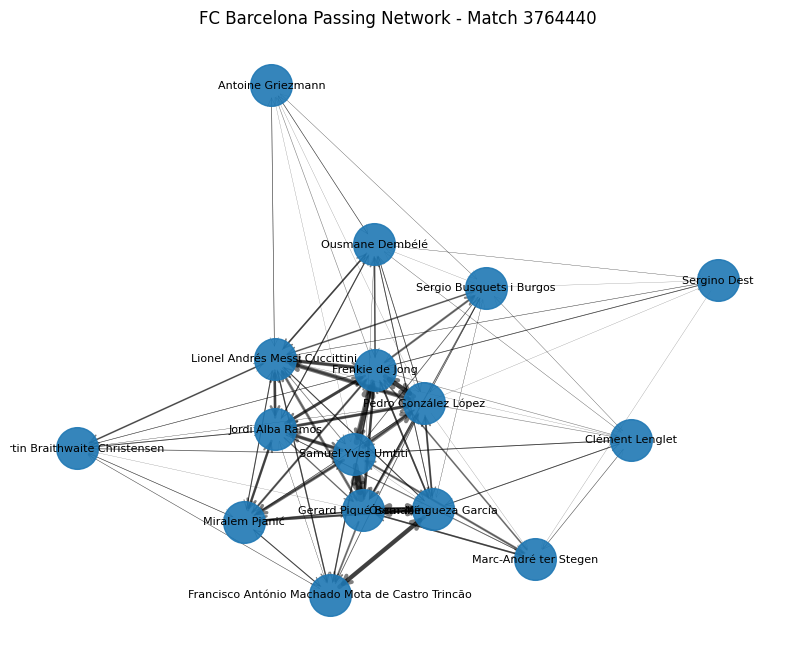

In [10]:
# Plotting one match Network

import matplotlib.pyplot as plt
import networkx as nx

# Escoge un partido cualquiera
match_id = list(graphs.keys())[0]
G = graphs[match_id]

plt.figure(figsize=(10, 8))

# Layout automático
pos = nx.spring_layout(G, seed=42, k=0.8)

# Grosor de edges según número de pases
weights = [G[u][v]["weight"] for u, v in G.edges()]
edge_widths = [w / max(weights) * 5 for w in weights]

nx.draw_networkx_nodes(
    G, pos,
    node_size=900,
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    arrows=True,
    arrowstyle="->",
    arrowsize=15,
    alpha=0.5
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title(f"FC Barcelona Passing Network - Match {match_id}")
plt.axis("off")
plt.show()

In [1]:
import networkx as nx
import pandas as pd
from collections import defaultdict, Counter
import random
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

# Cambia estos nombres si en tu dataframe se llaman distinto
PLAYER_FROM_COL = "player"
PLAYER_TO_COL = "pass_recipient"

# Si tienes una columna de match_id, déjala así.
# Si no existe, no pasa nada para la red agregada.
MATCH_COL = "match_id"

# Dataset con todos los pases de los 35 partidos
df = passes_df.copy()

# Nos quedamos solo con pases válidos
df = df.dropna(subset=[PLAYER_FROM_COL, PLAYER_TO_COL])

print("Number of passes:", len(df))
print("Number of players:", len(set(df[PLAYER_FROM_COL]) | set(df[PLAYER_TO_COL])))

NameError: name 'passes_df' is not defined